## Objective
Load ImageNet-pretrained DenseNet-121 weights, freeze the entire feature extractor,
and fine-tune only the new dropout classification head. Tests whether ImageNet transfer
learning provides a stronger starting point than training from scratch.
 
## Architecture Changes
 
| Component | 04. Dropout Weighted | 05. Pretrained Weighted |
|---|---|---|
| Pretrained | False | **True (ImageNet)** |
| Frozen backbone | False | **True** |
| Hidden dim | 256 | 256 |
| Head structure | Linear → ReLU → Dropout → Linear | Linear → ReLU → Dropout → Linear |
| Dropout | 0.5 | **0.4** |
| Pos weight | enabled | enabled |
| Optimiser | AdamW | AdamW |
| Weight decay | 1e-4 | 1e-4 |
| LR | 1e-3 | 1e-3 |
| Epochs | 30 | 30 |
 
## Hypothesis
DenseNet-121 pre-trained on ImageNet has already learned hierarchical features (edges,
textures, patterns) relevant to dermoscopic images. Freezing the backbone prevents
catastrophic forgetting of these features and reduces the trainable parameter count
to just the classification head. Dropout is slightly reduced to 0.4 (from 0.5) since
the frozen backbone already acts as a structural constraint on the feature space.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd
 
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
set_seed(42)
 
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
 
_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)
 
train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_densenet121(
    num_classes=1,
    pretrained=True,
    freeze_backbone=True,
    dropout=0.4,
    hidden_dim=256,
).to(device)
 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
 
# Only optimise the trainable classifier head
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,
)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: True | Frozen: True | Dropout: 0.4 | Hidden dim: 256 | Head: Linear → ReLU → Dropout → Linear')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\1008462/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30.8M/30.8M [00:03<00:00, 9.75MB/s]


Trainable params: 262,657 / 7,216,513
Pretrained: True | Frozen: True | Dropout: 0.4 | Hidden dim: 256 | Head: Linear → ReLU → Dropout → Linear


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_pretrained_weighted_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 1.0369, Bal Acc: 0.6856, Recall: 0.7149, F2: 0.4764, AUC: 0.7542
  Val   | Loss: 0.9503, Bal Acc: 0.7275, Recall: 0.9661, F2: 0.5465, AUC: 0.8411
  -> Saved best model (val AUC: 0.8411)


Epoch [2/30]
  Train | Loss: 0.9269, Bal Acc: 0.7300, Recall: 0.7742, F2: 0.5286, AUC: 0.8087
  Val   | Loss: 0.9902, Bal Acc: 0.7219, Recall: 0.9746, F2: 0.5417, AUC: 0.8487
  -> Saved best model (val AUC: 0.8487)


Epoch [3/30]
  Train | Loss: 0.9193, Bal Acc: 0.7312, Recall: 0.7799, F2: 0.5302, AUC: 0.8124
  Val   | Loss: 0.8634, Bal Acc: 0.7507, Recall: 0.9237, F2: 0.5686, AUC: 0.8516
  -> Saved best model (val AUC: 0.8516)


Epoch [4/30]
  Train | Loss: 0.8882, Bal Acc: 0.7427, Recall: 0.7925, F2: 0.5440, AUC: 0.8270
  Val   | Loss: 0.9140, Bal Acc: 0.7301, Recall: 0.9703, F2: 0.5492, AUC: 0.8551
  -> Saved best model (val AUC: 0.8551)


Epoch [5/30]
  Train | Loss: 0.8904, Bal Acc: 0.7412, Recall: 0.7845, F2: 0.5422, AUC: 0.8262
  Val   | Loss: 0.9297, Bal Acc: 0.7156, Recall: 0.9703, F2: 0.5358, AUC: 0.8584
  -> Saved best model (val AUC: 0.8584)


...

Epoch [26/30]
  Train | Loss: 0.7912, Bal Acc: 0.7915, Recall: 0.8575, F2: 0.6053, AUC: 0.8680
  Val   | Loss: 0.8236, Bal Acc: 0.7648, Recall: 0.8602, F2: 0.5840, AUC: 0.8530


Epoch [27/30]
  Train | Loss: 0.7924, Bal Acc: 0.7816, Recall: 0.8392, F2: 0.5929, AUC: 0.8668
  Val   | Loss: 0.8272, Bal Acc: 0.7658, Recall: 0.8856, F2: 0.5851, AUC: 0.8533


Epoch [28/30]
  Train | Loss: 0.7935, Bal Acc: 0.7800, Recall: 0.8438, F2: 0.5904, AUC: 0.8664
  Val   | Loss: 0.8264, Bal Acc: 0.7703, Recall: 0.8856, F2: 0.5904, AUC: 0.8528


Epoch [29/30]
  Train | Loss: 0.7992, Bal Acc: 0.7759, Recall: 0.8267, F2: 0.5857, AUC: 0.8605
  Val   | Loss: 0.8285, Bal Acc: 0.7713, Recall: 0.8983, F2: 0.5915, AUC: 0.8544


Epoch [30/30]
  Train | Loss: 0.8071, Bal Acc: 0.7726, Recall: 0.8267, F2: 0.5813, AUC: 0.8618
  Val   | Loss: 0.8251, Bal Acc: 0.7672, Recall: 0.8856, F2: 0.5867, AUC: 0.8540


## Plot Train and Validation Curves

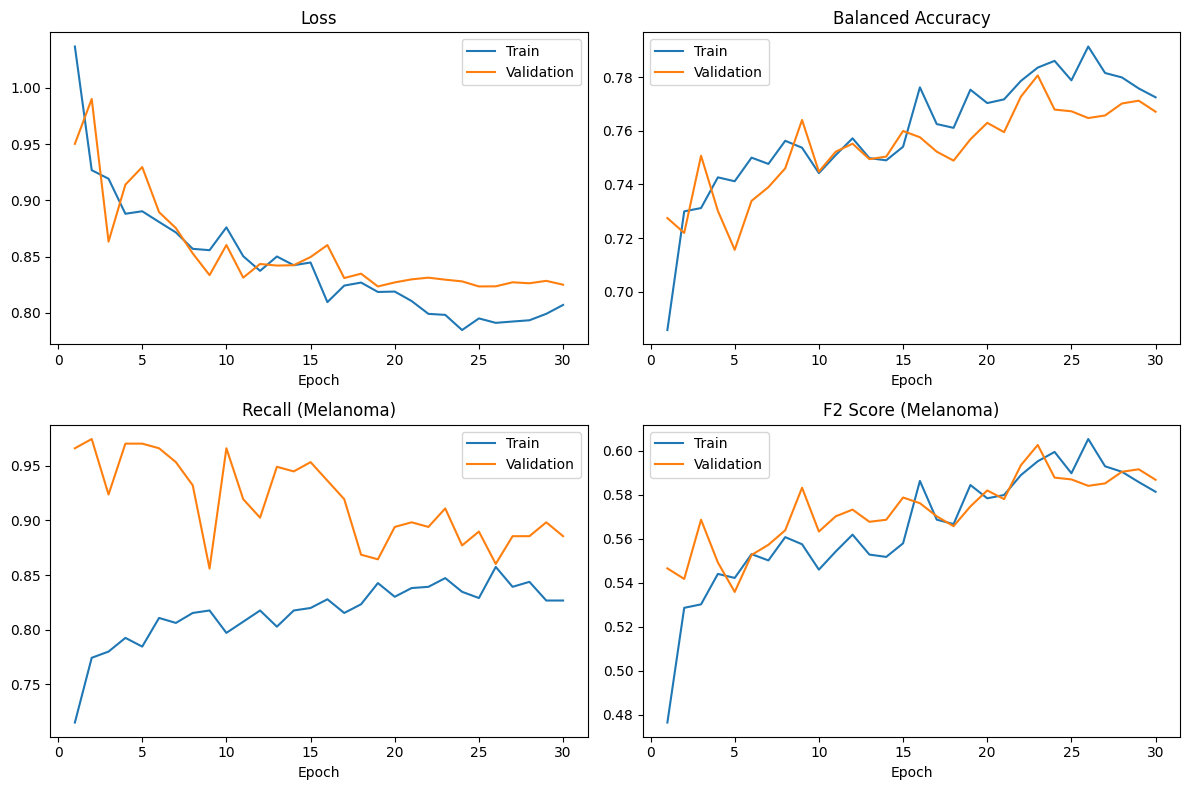

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_pretrained_weighted_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

C:\Users\1008462\AppData\Local\Temp\ipykernel_39388\3373308985.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(str(ROOT / 'models/densen

Best threshold: 0.68 | Val F2: 0.5918


## Test Set Evaluation

Threshold:          0.68
AUC-ROC:            0.8449
Balanced Accuracy:  0.7434
F2 Score:           0.5516

              precision    recall  f1-score   support

Non-Melanoma     0.9650    0.6799    0.7977      1340
    Melanoma     0.2434    0.8070    0.3740       171

    accuracy                         0.6942      1511
   macro avg     0.6042    0.7434    0.5859      1511
weighted avg     0.8834    0.6942    0.7498      1511



C:\Users\1008462\Desktop\50.021_project_group4\venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


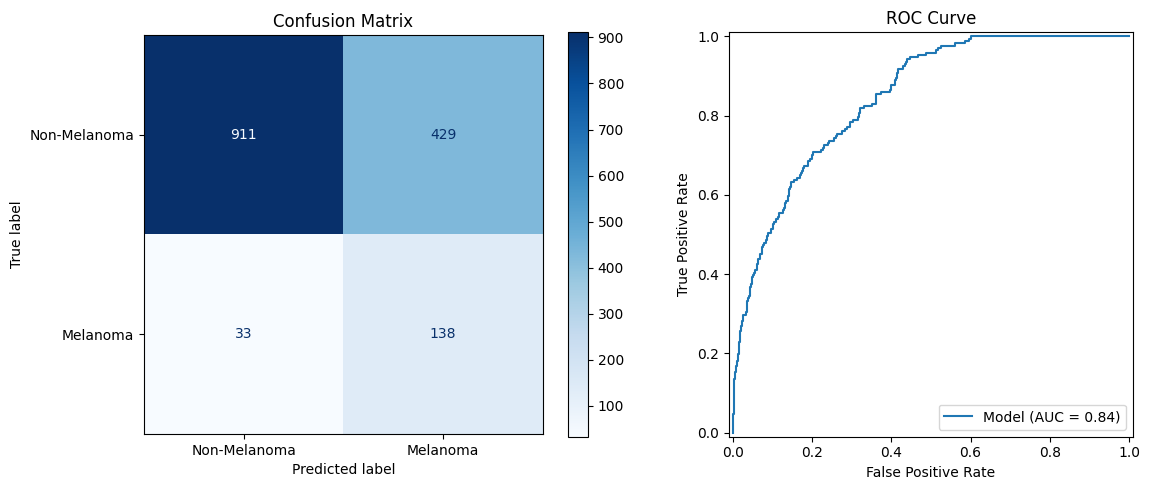

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)